In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

mean_df = pd.read_csv("results/strides/curve_mean.csv")
chi_df = pd.read_csv("results/strides/curve_chi.csv")
summary_df = pd.read_csv("results/strides/summary.csv")

/tmp/ipykernel_20827/94916343.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


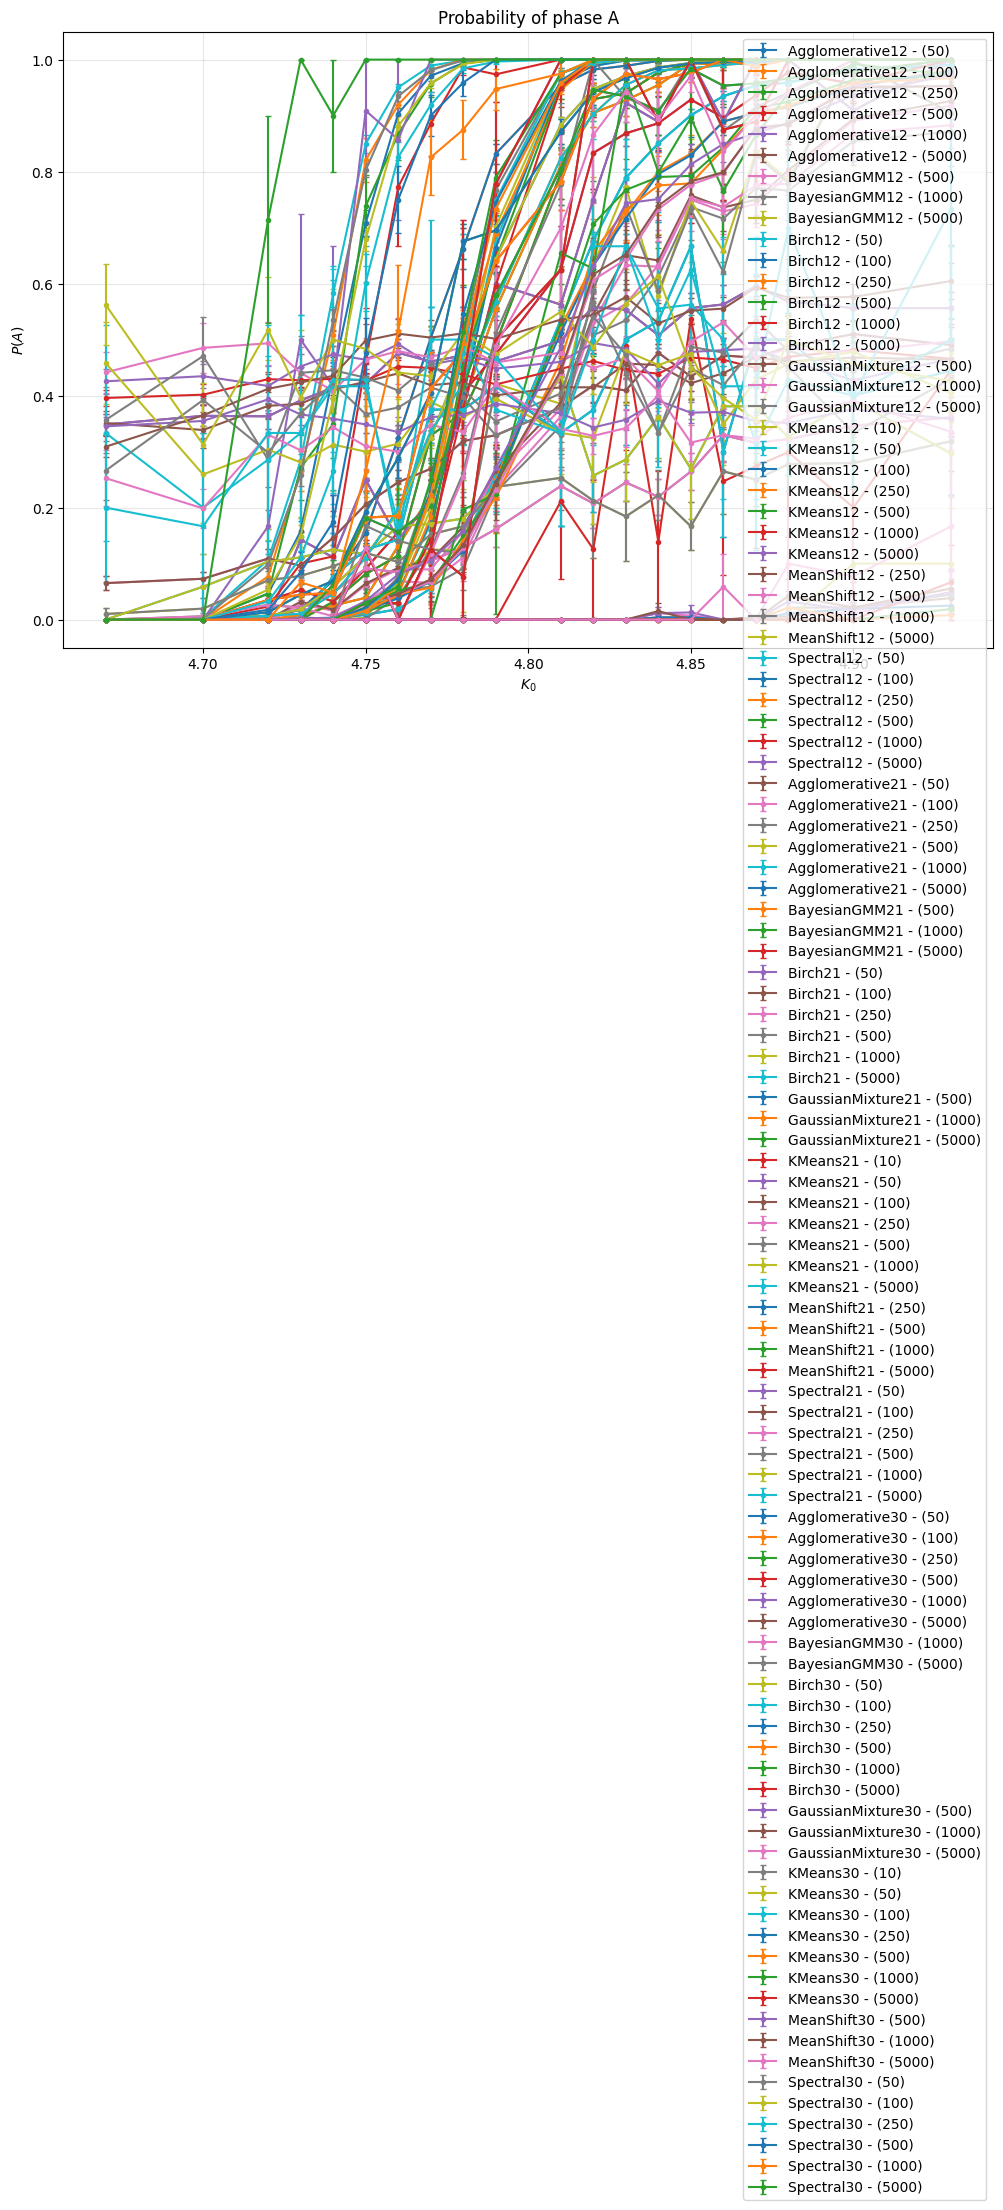

In [2]:
plt.figure(figsize=(12, 8))

for (feature_set, model, stride), group in mean_df.groupby(
    ["feature_set", "model", "stride"]
):
    # for 
    group = group.sort_values("K0")

    plt.errorbar(
    group["K0"],
    group["mean"],
    yerr=group["mean_err"],
    fmt="-o",
    markersize=3,
    capsize=2,
    linewidth=1.5,
    label=f"{model}{feature_set} - ({stride})"
        )

plt.xlabel(r"$K_0$")
plt.ylabel(r"$P(A)$")
plt.title("Probability of phase A")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# plt.savefig(
#     "results/figures/probability_all_models.png",
#     dpi=300
# )

plt.show()

In [3]:
# feature_sets = sorted(mean_df["feature_set"].unique())
# strides = ["5000", "1000", "500", "100","50","10"]

# fig, axes = plt.subplots(
#     len(feature_sets),
#     len(strides),
#     figsize=(14, 4 * len(feature_sets)),
#     sharex=True,
#     sharey=True
# )

# # przypadek gdy jest tylko jeden feature_set
# if len(feature_sets) == 1:
#     axes = np.array([axes])

# for i, fs in enumerate(feature_sets):

#     for j, stid in enumerate(strides):

#         ax = axes[i, j]

#         df_plot = mean_df[
#             (mean_df["feature_set"] == fs)
#             &
#             (mean_df["stride"] == stid)
#         ]

#         for model, group in df_plot.groupby("model"):

#             group = group.sort_values("K0")

#             ax.errorbar(
#                 group["K0"],
#                 group["mean"],
#                 yerr=group["mean_err"],
#                 fmt="-o",
#                 markersize=3,
#                 capsize=2,
#                 linewidth=1.2,
#                 label=model
#             )

#         ax.set_title(
#             f"Feature set {fs} — {stid}"
#         )

#         ax.grid(alpha=0.3)

#         if j == 0:
#             ax.set_ylabel(r"$P(A)$")

#         if i == len(feature_sets) - 1:
#             ax.set_xlabel(r"$K_0$")

#         ax.legend(
#             fontsize=7,
#             loc="best"
#         )

# plt.suptitle(
#     "Strides",
#     fontsize=16,
#     y=1.02
# )

# plt.tight_layout()
# plt.show()

In [4]:
# feature_sets = sorted(chi_df["feature_set"].unique())
# calibrations = ["uncalibrated", "calibrated"]

# fig, axes = plt.subplots(
#     len(feature_sets),
#     len(calibrations),
#     figsize=(14, 4 * len(feature_sets)),
#     sharex=True,
#     sharey=True
# )

# # przypadek gdy jest tylko jeden feature_set
# if len(feature_sets) == 1:
#     axes = np.array([axes])

# for i, fs in enumerate(feature_sets):

#     for j, calib in enumerate(calibrations):

#         ax = axes[i, j]

#         df_plot = chi_df[
#             (chi_df["feature_set"] == fs)
#             &
#             (chi_df["calibration"] == calib)
#         ]

#         for model, group in df_plot.groupby("model"):

#             group = group.sort_values("K0")

#             ax.errorbar(
#                 group["K0"],
#                 group["chi"],
#                 yerr=group["chi_err"],
#                 fmt="-o",
#                 markersize=3,
#                 capsize=2,
#                 linewidth=1.2,
#                 label=model
#             )

#         ax.set_title(
#             f"Feature set {fs} — {calib}"
#         )

#         ax.grid(alpha=0.3)

#         if j == 0:
#             ax.set_ylabel(r"$Chi$")

#         if i == len(feature_sets) - 1:
#             ax.set_xlabel(r"$K_0$")

#         ax.legend(
#             fontsize=7,
#             loc="best"
#         )

# plt.suptitle(
#     "Calibrated vs Uncalibrated",
#     fontsize=16,
#     y=1.02
# )

# plt.tight_layout()
# plt.show()

In [5]:
table = (
    summary_df[
        [
            "model",
            "n_features",
            "stride",
            "K0_crit",
            "K0_crit_err",
            "K0_close",
            "runtime_total",
        ]
    ]
    .sort_values(
        ["model", "n_features", "stride"]
    )
)

print(table.to_string(index=False))

          model  n_features  stride  K0_crit  K0_crit_err  K0_close  runtime_total
  Agglomerative          12      50 4.807467     0.001214      4.81         21.911
  Agglomerative          12     100 4.769837     0.001189      4.77          7.538
  Agglomerative          12     250 4.786795     0.003460      4.79          3.400
  Agglomerative          12     500 4.790438     0.003804      4.79          2.761
  Agglomerative          12    1000 4.793478     0.010745      4.79          1.684
  Agglomerative          12    5000 4.785556     0.008553      4.81          0.178
  Agglomerative          21      50 4.810322     0.003331      4.81         26.571
  Agglomerative          21     100 4.891144     0.019581      4.93          8.708
  Agglomerative          21     250      NaN          NaN       NaN          3.605
  Agglomerative          21     500      NaN          NaN       NaN          3.073
  Agglomerative          21    1000      NaN          NaN       NaN          1.862
  Ag

In [6]:
table = (
    summary_df[
        [
            "model",
            "n_features",
            "stride",
            "K0_crit",
            "K0_crit_err",
            "runtime_total",
        ]
    ]
    .sort_values(
        ["model", "n_features", "stride"]
    )
)

table["K0_crit"] = table["K0_crit"].round(4)
table["K0_crit_err"] = table["K0_crit_err"].round(4)
table["runtime_total"] = table["runtime_total"].round(2)

print(table.to_string(index=False))

          model  n_features  stride  K0_crit  K0_crit_err  runtime_total
  Agglomerative          12      50   4.8075       0.0012          21.91
  Agglomerative          12     100   4.7698       0.0012           7.54
  Agglomerative          12     250   4.7868       0.0035           3.40
  Agglomerative          12     500   4.7904       0.0038           2.76
  Agglomerative          12    1000   4.7935       0.0107           1.68
  Agglomerative          12    5000   4.7856       0.0086           0.18
  Agglomerative          21      50   4.8103       0.0033          26.57
  Agglomerative          21     100   4.8911       0.0196           8.71
  Agglomerative          21     250      NaN          NaN           3.60
  Agglomerative          21     500      NaN          NaN           3.07
  Agglomerative          21    1000      NaN          NaN           1.86
  Agglomerative          21    5000   4.8300       0.0151           0.17
  Agglomerative          30      50   4.7817       

In [8]:
table = summary_df.copy()

table["K0"] = (
    table["K0_crit"].round(4).astype(str)
    + " ± "
    + table["K0_crit_err"].round(4).astype(str)
)

table = table[
    [
        "model",
        "n_features",
        "stride",
        "K0",
        "K0_close",
        "runtime_total",
    ]
]

table = table.sort_values(
    ["model", "n_features", "stride"]
)

print(table.to_string(index=False))

          model  n_features  stride              K0  K0_close  runtime_total
  Agglomerative          12      50 4.8075 ± 0.0012      4.81         21.911
  Agglomerative          12     100 4.7698 ± 0.0012      4.77          7.538
  Agglomerative          12     250 4.7868 ± 0.0035      4.79          3.400
  Agglomerative          12     500 4.7904 ± 0.0038      4.79          2.761
  Agglomerative          12    1000 4.7935 ± 0.0107      4.79          1.684
  Agglomerative          12    5000 4.7856 ± 0.0086      4.81          0.178
  Agglomerative          21      50 4.8103 ± 0.0033      4.81         26.571
  Agglomerative          21     100 4.8911 ± 0.0196      4.93          8.708
  Agglomerative          21     250       nan ± nan       NaN          3.605
  Agglomerative          21     500       nan ± nan       NaN          3.073
  Agglomerative          21    1000       nan ± nan       NaN          1.862
  Agglomerative          21    5000   4.83 ± 0.0151      4.83          0.168

In [9]:
summary_clean = summary_df.dropna(
    subset=["K0_crit"]
)

summary_table = (
    summary_clean
    .groupby(["n_features", "stride"])
    .agg(
        K0_crit_mean=("K0_crit", "mean"),
        K0_crit_std=("K0_crit", "std"),
        Err_mean=("K0_crit_err", "mean"),
        Runtime_mean=("runtime_total", "mean"),
        N_models=("model", "nunique")
    )
    .reset_index()
)
summary_table

,n_features,stride,K0_crit_mean,K0_crit_std,Err_mean,Runtime_mean,N_models
0,12,10,4.782503,NaN,0.000645,4.596000,1
1,12,50,4.783850,0.033109,0.001014,56.084500,4
2,12,100,4.766459,0.017390,0.001098,12.698000,4
3,12,250,4.773484,0.022731,0.002745,3.881250,4
4,12,500,4.790394,0.027208,0.003071,3.061167,6
5,12,1000,4.793580,0.025025,0.006256,1.834500,6
6,12,5000,4.785729,0.031327,0.007119,0.290000,6
7,21,50,4.810322,0.000000,0.003331,33.388500,2
8,21,100,4.844532,0.080734,0.020933,24.222333,3
9,21,250,4.851105,NaN,0.010475,3.611000,1


In [10]:
summary_clean = summary_df.dropna(
    subset=["K0_crit"]
)

summary_table = (
    summary_clean
    .groupby(["n_features"])
    .agg(
        K0_crit_mean=("K0_crit", "mean"),
        K0_crit_std=("K0_crit", "std"),
        Err_mean=("K0_crit_err", "mean"),
        Runtime_mean=("runtime_total", "mean"),
        N_models=("model", "nunique")
    )
    .reset_index()
)
summary_table

,n_features,K0_crit_mean,K0_crit_std,Err_mean,Runtime_mean,N_models
0,12,4.783739,0.025802,0.003831,10.527903,6
1,21,4.811339,0.047613,0.009300,8.716526,6
2,30,4.777600,0.021479,0.003458,13.782667,6


In [11]:
table = summary_df.copy()

table = table[
    (table["n_features"] == 30)
    &(
    (table["stride"] == 50)
    |
    (table["stride"] == 10)
    )]

table = table[
    [
        "model",
        "K0_close",
        "runtime_total",
    ]
]

table = table.sort_values(
    ["model"]
)

print(table.to_string(index=False))

        model  K0_close  runtime_total
Agglomerative      4.78         24.967
        Birch      4.78         44.171
       KMeans      4.78          3.620
       KMeans      4.78          4.822
     Spectral      4.74        210.827
